# Exploratory Data Analysis - Club Piscine MMM

This notebook performs exploratory analysis on the cleaned datasets to understand:
1. **Time series patterns** in sales revenue and media spend
2. **Correlations** between media channels and sales revenue
3. **Seasonality** in the business
4. **Key insights** for building the MMM model

---

In [ ]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display settings - show ALL rows/columns (no truncation)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_palette('husl')

# Paths
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path = project_root / 'reports' / 'figures'

# Create figures directory if it doesn't exist
figures_path.mkdir(parents=True, exist_ok=True)

print(f"Loading data from: {processed_path}")
print(f"Saving figures to: {figures_path}")

In [ ]:
# Cell 2: Load Cleaned Datasets

# Load from CSV (more portable across pandas versions)
sales_data = pd.read_csv(processed_path / 'sales_data.csv')
budget = pd.read_csv(processed_path / 'budget_media_spend.csv')
tableau_medias = pd.read_csv(processed_path / 'tableau_medias_performance.csv')
calendrier = pd.read_csv(processed_path / 'calendrier_fiscal.csv')

# Load pre-merged dataset (sales + media spend, merged in NB02)
merged = pd.read_csv(processed_path / 'sales_spend_merged.csv')

# Convert date columns
sales_data['date'] = pd.to_datetime(sales_data['date'], errors='coerce')
merged['date'] = pd.to_datetime(merged['date'], errors='coerce')
tableau_medias['date_debut'] = pd.to_datetime(tableau_medias['date_debut'], errors='coerce')
tableau_medias['date_fin'] = pd.to_datetime(tableau_medias['date_fin'], errors='coerce')
calendrier['Date'] = pd.to_datetime(calendrier['Date'], errors='coerce')

# Derive fiscal_month_pos if not present (Nov=1, Dec=2, ..., Oct=12)
if 'fiscal_month_pos' not in sales_data.columns:
    sales_data['fiscal_month_pos'] = (sales_data['month_num'] - 11) % 12 + 1

print("Datasets loaded:")
print(f"  - Sales Data: {sales_data.shape}")
print(f"  - Budget (Media Spend): {budget.shape}")
print(f"  - Merged (Sales + Spend): {merged.shape}  [merged in NB02]")
print(f"  - Tableau Medias: {tableau_medias.shape}")
print(f"  - Calendrier Fiscal: {calendrier.shape}")

# ============================================================
# FISCAL YEAR STRUCTURE
# ============================================================
print("\n" + "=" * 70)
print("FISCAL YEAR STRUCTURE")
print("=" * 70)
print("""
Club Piscine fiscal year: November to October
  FY2023 = Nov 2022 - Oct 2023
  FY2024 = Nov 2023 - Oct 2024
  FY2025 = Nov 2024 - Oct 2025

Both SALES and BUDGET data use fiscal year in 'year' column.
Direct merge on (year, month_num) performed in NB02.
""")

# ============================================================
# DATA AVAILABILITY DIAGNOSTIC
# ============================================================
print("=" * 70)
print("DATA AVAILABILITY DIAGNOSTIC")
print("=" * 70)

# Define 6 product categories (all equal)
product_cols = {
    'piscines_hors_terre_revenue': 'HT (Above-Ground Pools)',
    'piscines_creusees_revenue': 'CR (In-Ground Pools)',
    'spas_revenue': 'SP (Spas)',
    'meubles_gazebo_revenue': 'ME&GA (Furniture & Gazebo)',
    'fitness_revenue': 'FI (Fitness)',
    'bbq_revenue': 'BQ (BBQ)',
}

print(f"\n{'FY':<6} {'Month':<12} {'#':<4} {'Total Revenue':>16} {'Has Data?':<10}")
print("-" * 50)
for _, row in sales_data.iterrows():
    total = row['total_all_revenue']
    has = "YES" if pd.notna(total) and total > 0 else "NO"
    print(f"{int(row['year']):<6} {row['month']:<12} {int(row['month_num']):<4} ${total:>14,.0f} {has}")

print(f"\nAll 36 months have complete data across all 6 product categories.")
print(f"Columns: {sales_data.columns.tolist()}")

---
## 1. Sales Revenue Analysis

Understanding the dependent variable for our MMM - sales revenue by product category.

In [ ]:
# Cell 3: Sales Revenue Overview - All 6 Categories Equal
print("=" * 60)
print("SALES REVENUE OVERVIEW - 6 PRODUCT CATEGORIES")
print("=" * 60)

available_years = sorted(merged['year'].unique())

# Revenue columns for all 6 categories
revenue_cols = list(product_cols.keys())
product_labels = product_cols  # from Cell 2

print("\nTotal Revenue by Fiscal Year:")
print("-" * 50)
for fy in available_years:
    total = merged[merged['year'] == fy]['total_all_revenue'].sum()
    print(f"  FY{fy}: ${total:,.0f}")

# ============================================================
# YEAR-OVER-YEAR GROWTH - ALL 6 CATEGORIES EQUALLY
# ============================================================
print("\n" + "=" * 60)
print("YEAR-OVER-YEAR GROWTH BY PRODUCT (REVENUE)")
print("=" * 60)

for i in range(len(available_years) - 1):
    year1, year2 = available_years[i], available_years[i + 1]
    print(f"\nFY{year1} vs FY{year2} (Full 12 months each)")
    print(f"\n{'Product':<35} {'FY' + str(year1):>15} {'FY' + str(year2):>15} {'Growth':>10}")
    print("-" * 75)
    
    for col, label in product_labels.items():
        val1 = merged[merged['year'] == year1][col].sum()
        val2 = merged[merged['year'] == year2][col].sum()
        growth = (val2 - val1) / val1 * 100 if val1 > 0 else 0
        print(f"{label:<35} ${val1:>13,.0f} ${val2:>13,.0f} {growth:>+9.1f}%")
    
    all1 = merged[merged['year'] == year1]['total_all_revenue'].sum()
    all2 = merged[merged['year'] == year2]['total_all_revenue'].sum()
    growth_all = (all2 - all1) / all1 * 100 if all1 > 0 else 0
    print("-" * 75)
    print(f"{'TOTAL REVENUE':<35} ${all1:>13,.0f} ${all2:>13,.0f} {growth_all:>+9.1f}%")

# Revenue share by category
print("\n" + "=" * 60)
print("REVENUE SHARE BY PRODUCT CATEGORY")
print("=" * 60)
for fy in available_years:
    fy_data = merged[merged['year'] == fy]
    total = fy_data['total_all_revenue'].sum()
    print(f"\nFY{fy} (Total: ${total:,.0f}):")
    for col, label in product_labels.items():
        val = fy_data[col].sum()
        pct = val / total * 100
        print(f"  {label:<35} ${val:>12,.0f}  ({pct:5.1f}%)")

# Units (only HT, CR, SP have unit data)
print("\n" + "=" * 60)
print("UNITS SOLD BY FISCAL YEAR (Categories with unit tracking)")
print("=" * 60)
unit_cols = {
    'piscines_hors_terre_units': 'HT (Above-Ground Pools)',
    'piscines_creusees_units': 'CR (In-Ground Pools)',
    'spas_units': 'SP (Spas)',
}
for fy in available_years:
    fy_data = merged[merged['year'] == fy]
    print(f"\nFY{fy}:")
    for col, label in unit_cols.items():
        print(f"  {label}: {fy_data[col].sum():,.0f} units")
    print(f"  Total Units: {fy_data['total_units'].sum():,.0f}")
print("\nNote: ME&GA, FI, BQ only have revenue data (no unit tracking in source file)")

In [ ]:
# Cell 4: Sales Revenue Time Series - ALL 6 CATEGORIES EQUAL

# fiscal_month_pos already in merged data (from NB02)
fiscal_month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr',
                       'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

available_fiscal_years = sorted(merged['year'].unique())

# ============================================================
# PLOT 1: TOTAL REVENUE BY FISCAL YEAR (all products combined)
# ============================================================
fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(4, 1, hspace=0.35)

ax_top = fig.add_subplot(gs[0, 0])
fy_colors = plt.cm.tab10(np.linspace(0, 1, len(available_fiscal_years)))

for idx, fy in enumerate(available_fiscal_years):
    data = merged[merged['year'] == fy].sort_values('fiscal_month_pos')
    ax_top.plot(data['fiscal_month_pos'], data['total_all_revenue'],
                marker='o', linewidth=2, markersize=8,
                label=f'FY{fy}', color=fy_colors[idx])

ax_top.set_xlabel('Fiscal Year Month')
ax_top.set_ylabel('Total Revenue ($)')
ax_top.set_title('Monthly Total Revenue (All 6 Categories) - Fiscal Year Comparison',
                 fontsize=14, fontweight='bold')
ax_top.set_xticks(range(1, 13))
ax_top.set_xticklabels(fiscal_month_labels)
ax_top.legend(title='Fiscal Year', loc='best')
ax_top.grid(True, alpha=0.3)
ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# ============================================================
# PLOTS 2-4: ALL 6 PRODUCTS PER FISCAL YEAR (equal treatment)
# ============================================================
all_categories = list(product_cols.keys())
all_labels = list(product_cols.values())
cat_colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#1abc9c', '#9b59b6']

for idx, fy in enumerate(available_fiscal_years):
    ax = fig.add_subplot(gs[idx + 1, 0])
    fy_data = merged[merged['year'] == fy].sort_values('fiscal_month_pos')

    for cat, label, color in zip(all_categories, all_labels, cat_colors):
        ax.plot(fy_data['fiscal_month_pos'], fy_data[cat],
                marker='o', linewidth=2, label=label, color=color)

    ax.set_xlabel('Fiscal Year Month')
    ax.set_ylabel('Revenue ($)')
    ax.set_title(f'FY{fy} - All 6 Product Categories', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(fiscal_month_labels)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(figures_path / 'sales_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: Category-level comparison across FYs (small multiples)
# ============================================================
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

for i, (cat, label) in enumerate(product_cols.items()):
    ax = axes2[i]
    for idx, fy in enumerate(available_fiscal_years):
        fy_data = merged[merged['year'] == fy].sort_values('fiscal_month_pos')
        ax.plot(fy_data['fiscal_month_pos'], fy_data[cat],
                marker='o', linewidth=2, label=f'FY{fy}', color=fy_colors[idx])
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(fiscal_month_labels, fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

fig2.suptitle('Revenue by Category - Year-over-Year Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'all_products_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# Revenue composition
print("\nRevenue Composition by Fiscal Year:")
print("=" * 70)
for fy in available_fiscal_years:
    fy_data = merged[merged['year'] == fy]
    total = fy_data['total_all_revenue'].sum()
    print(f"\nFY{fy} (Total: ${total:,.0f}):")
    for col, label in product_cols.items():
        val = fy_data[col].sum()
        pct = val / total * 100
        print(f"  {label:<35} ${val:>12,.0f}  ({pct:5.1f}%)")

print("\nKey Insights:")
print("  - Peak season: March-June (fiscal months 5-8)")
print("  - ME&GA is the largest single category by revenue")
print("  - Each category has distinct seasonal patterns")
print("  - FI and BQ are smaller but still included in MMM")

---
## 2. Media Spend Analysis (Budget)

Understanding the marketing investments across different channels.

In [5]:
# Cell 5: Media Spend Overview - Multi-Year Comparison
print("=" * 80)
print("MEDIA SPEND COMPARISON: FISCAL YEARS")
print("=" * 80)
print("""
Fiscal Year Definition:
   - Fiscal 2023 = November 2022 -> October 2023
   - Fiscal 2024 = November 2023 -> October 2024
   - Fiscal 2025 = November 2024 -> October 2025

Note: Budget data is organized by fiscal year (Nov-Oct).
   The 'year' column in budget data refers to the FISCAL year.
   
Channel Groups (7 channels):
   Television, Radio, Panneaux, Social_Media, Preroll,
   Banniere_Web, Circulaire_Digitale
""")

# Get available fiscal years
available_fiscal_years = sorted(budget['year'].unique())
print(f"Available fiscal years in data: {available_fiscal_years}")

# ============================================================
# DETAILED CHANNEL COMPARISON (All Available Years)
# ============================================================
print("\n" + "=" * 80)
print("MEDIA SPEND BY CHANNEL - FISCAL YEAR COMPARISON")
print("=" * 80)

# Pivot by channel and year
channel_comparison = budget.pivot_table(
    index='channel_group', 
    columns='year', 
    values='spend', 
    aggfunc='sum', 
    fill_value=0
)

# Calculate totals for each year
year_totals = {year: channel_comparison[year].sum() for year in available_fiscal_years}

# Add percentage columns for each year
for year in available_fiscal_years:
    channel_comparison[f'% of FY{year}'] = (channel_comparison[year] / year_totals[year] * 100) if year_totals[year] > 0 else 0

# Sort by most recent year spend
channel_comparison = channel_comparison.sort_values(available_fiscal_years[-1], ascending=False)

# Build dynamic header
print(f"\n{'Channel':<25}", end='')
for year in available_fiscal_years:
    print(f" {'FY ' + str(year):>12} {'% Total':>8}", end='')
print()
print("-" * (25 + len(available_fiscal_years) * 21))

for channel in channel_comparison.index:
    print(f"{channel:<25}", end='')
    for year in available_fiscal_years:
        spend = channel_comparison.loc[channel, year]
        pct = channel_comparison.loc[channel, f'% of FY{year}']
        print(f" ${spend:>10,.0f} {pct:>7.1f}%", end='')
    print()

print("-" * (25 + len(available_fiscal_years) * 21))
print(f"{'TOTAL':<25}", end='')
for year in available_fiscal_years:
    print(f" ${year_totals[year]:>10,.0f} {100:>7.1f}%", end='')
print()

# Year-over-year growth comparison
if len(available_fiscal_years) >= 2:
    print("\n" + "=" * 80)
    print("YEAR-OVER-YEAR GROWTH BY CHANNEL")
    print("=" * 80)
    
    for i in range(len(available_fiscal_years) - 1):
        year1 = available_fiscal_years[i]
        year2 = available_fiscal_years[i + 1]
        
        print(f"\n{year1} vs {year2}:")
        print(f"{'Channel':<25} {'FY {}'.format(year1):>12} {'FY {}'.format(year2):>12} {'Change':>12} {'% Change':>10}")
        print("-" * 70)
        
        for channel in channel_comparison.index:
            spend1 = channel_comparison.loc[channel, year1]
            spend2 = channel_comparison.loc[channel, year2]
            diff = spend2 - spend1
            
            if spend1 > 0:
                pct_chg = (spend2 - spend1) / spend1 * 100
                pct_str = f"{pct_chg:+.1f}%"
            elif spend2 > 0:
                pct_str = "NEW"
            else:
                pct_str = "-"
            
            print(f"{channel:<25} ${spend1:>10,.0f} ${spend2:>10,.0f} ${diff:>+10,.0f} {pct_str:>10}")
        
        total1 = year_totals[year1]
        total2 = year_totals[year2]
        total_diff = total2 - total1
        total_pct = (total2 - total1) / total1 * 100 if total1 > 0 else 0
        
        print("-" * 70)
        print(f"{'TOTAL':<25} ${total1:>10,.0f} ${total2:>10,.0f} ${total_diff:>+10,.0f} {total_pct:>+9.1f}%")

print("\nKey Observations:")
print("   - Television and Radio remain significant spend categories")
print("   - Digital channels (Preroll, Banniere_Web, Social_Media) show consistent presence")
print("   - Panneaux (Billboards) and Circulaire_Digitale round out the media mix")
print(f"   - Total budget evolution: {' -> '.join([f'FY{y}: ${year_totals[y]:,.0f}' for y in available_fiscal_years])}")

MEDIA SPEND COMPARISON: FISCAL YEARS

Fiscal Year Definition:
   - Fiscal 2023 = November 2022 -> October 2023
   - Fiscal 2024 = November 2023 -> October 2024
   - Fiscal 2025 = November 2024 -> October 2025

Note: Budget data is organized by fiscal year (Nov-Oct).
   The 'year' column in budget data refers to the FISCAL year.

Channel Groups (7 channels):
   Television, Radio, Panneaux, Social_Media, Preroll,
   Banniere_Web, Circulaire_Digitale

Available fiscal years in data: [np.int64(2023), np.int64(2024), np.int64(2025)]

MEDIA SPEND BY CHANNEL - FISCAL YEAR COMPARISON

Channel                        FY 2023  % Total      FY 2024  % Total      FY 2025  % Total
----------------------------------------------------------------------------------------
Television                $ 1,395,443    42.8% $ 1,047,568    38.2% $   870,000    30.2%
Radio                     $   677,603    20.8% $   662,606    24.2% $   789,863    27.5%
Banniere_Web              $   646,259    19.8% $   551,35

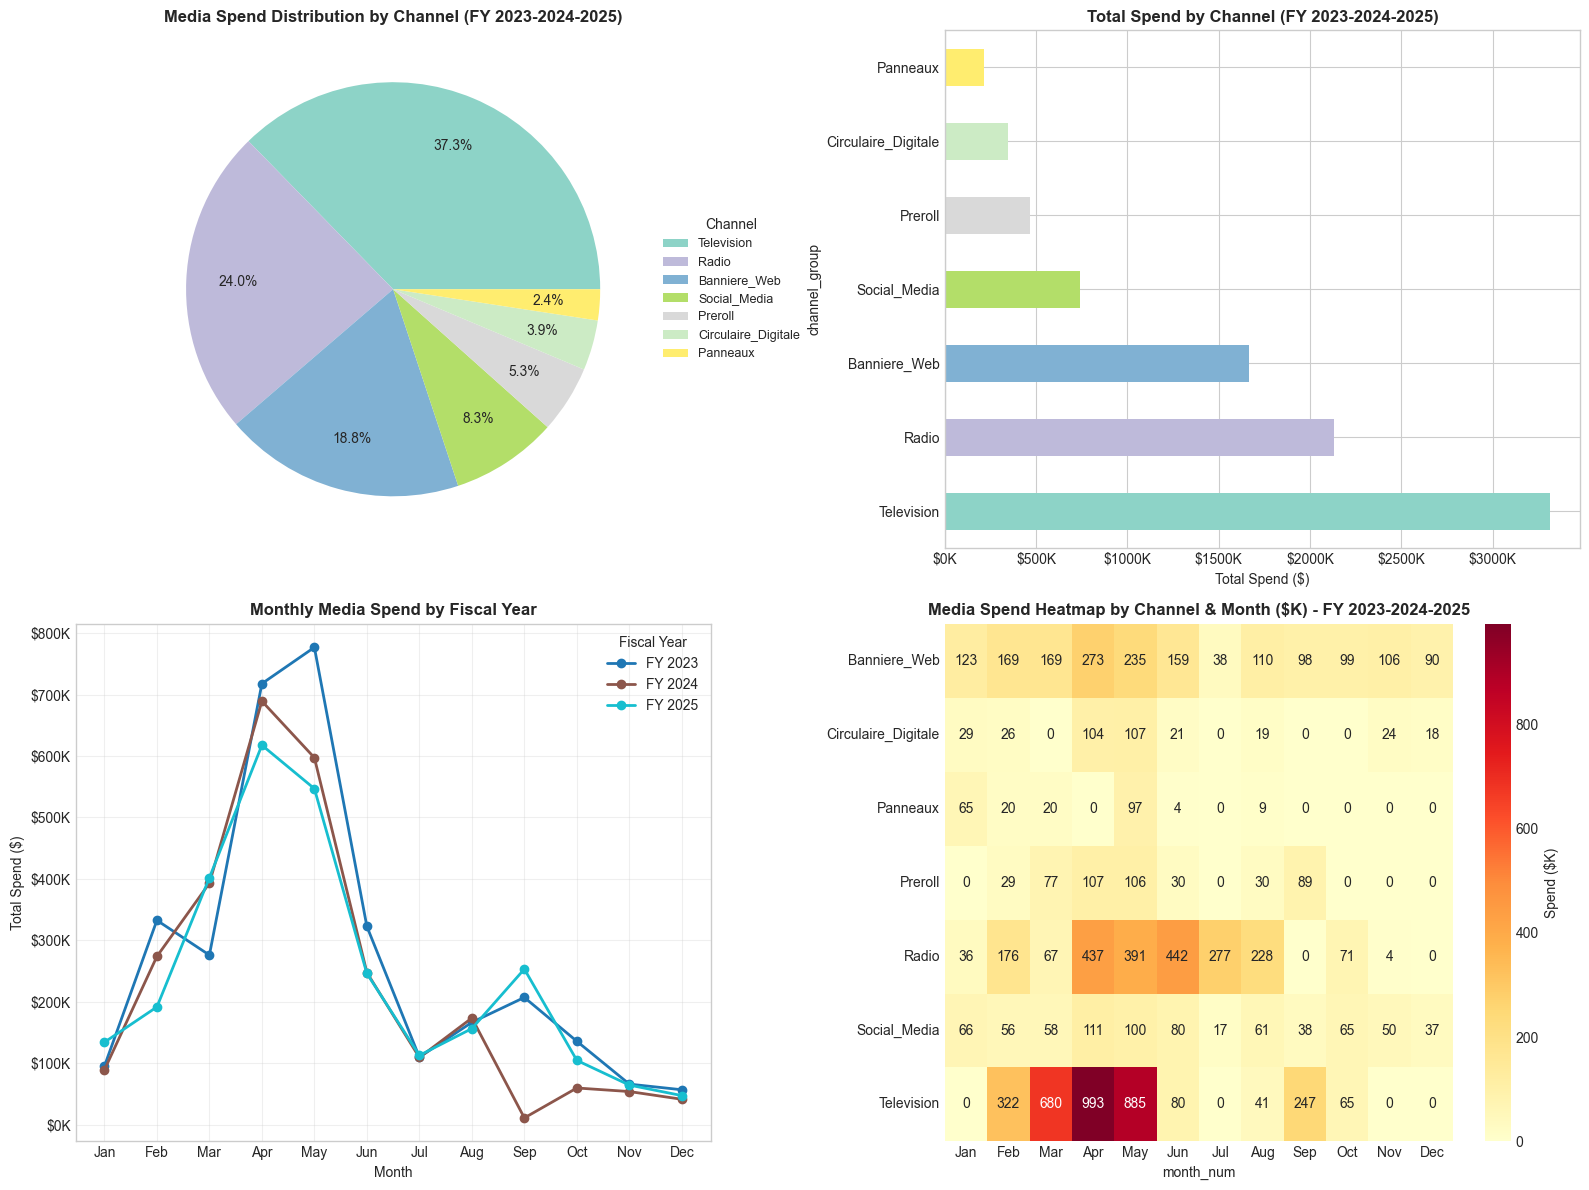


Key Insights:
  - Television and Radio are the largest spend channels
  - Media spend increases March-June, aligning with peak sales season
  - Digital channels (Preroll, Banniere_Web, Social_Media) have more consistent year-round presence
  - Data spans fiscal years: 2023, 2024, 2025


In [6]:
# Cell 6: Media Spend Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get available fiscal years
available_fiscal_years = sorted(budget['year'].unique())
year_colors = plt.cm.tab10(np.linspace(0, 1, len(available_fiscal_years)))

# Plot 1: Spend by channel (pie chart) - all years combined
ax1 = axes[0, 0]
channel_spend = budget.groupby('channel_group')['spend'].sum().sort_values(ascending=False)
colors = plt.cm.Set3(np.linspace(0, 1, len(channel_spend)))
wedges, texts, autotexts = ax1.pie(channel_spend, labels=None, autopct='%1.1f%%', 
                                    colors=colors, pctdistance=0.75)
ax1.legend(wedges, channel_spend.index, title="Channel", loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
years_str = '-'.join(map(str, available_fiscal_years))
ax1.set_title(f'Media Spend Distribution by Channel (FY {years_str})', fontsize=12, fontweight='bold')

# Plot 2: Spend by channel (bar chart) - all years combined
ax2 = axes[0, 1]
channel_spend.plot(kind='barh', ax=ax2, color=colors)
ax2.set_xlabel('Total Spend ($)')
ax2.set_title(f'Total Spend by Channel (FY {years_str})', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 3: Monthly spend over time (all years)
ax3 = axes[1, 0]
for idx, year in enumerate(available_fiscal_years):
    year_data = budget[budget['year'] == year].groupby('month_num')['spend'].sum()
    # Reindex to ensure all months are present
    year_data = year_data.reindex(range(1, 13), fill_value=0)
    ax3.plot(range(1, 13), year_data.values, marker='o', linewidth=2, 
             label=f'FY {year}', color=year_colors[idx])

ax3.set_xlabel('Month')
ax3.set_ylabel('Total Spend ($)')
ax3.set_title('Monthly Media Spend by Fiscal Year', fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.legend(title='Fiscal Year')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax3.grid(True, alpha=0.3)

# Plot 4: Spend by channel over months (heatmap) - all years combined
ax4 = axes[1, 1]
pivot = budget.pivot_table(index='channel_group', columns='month_num', 
                           values='spend', aggfunc='sum', fill_value=0)
pivot = pivot.reindex(columns=range(1, 13), fill_value=0)
sns.heatmap(pivot/1000, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax4, 
            cbar_kws={'label': 'Spend ($K)'})
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax4.set_title(f'Media Spend Heatmap by Channel & Month ($K) - FY {years_str}', 
              fontsize=12, fontweight='bold')
ax4.set_ylabel('')

plt.tight_layout()
plt.savefig(figures_path / 'media_spend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights:")
print("  - Television and Radio are the largest spend channels")
print("  - Media spend increases March-June, aligning with peak sales season")
print("  - Digital channels (Preroll, Banniere_Web, Social_Media) have more consistent year-round presence")
print(f"  - Data spans fiscal years: {', '.join(map(str, available_fiscal_years))}")

---
## 2b. Distribution Analysis

Understanding the distributions of our key variables (revenue and media spend) before correlation analysis.

Key questions:
- Are revenue/spend distributions skewed? (important for regression assumptions)
- Which spend channels have high zero-inflation? (impacts model reliability)

In [ ]:
# Distribution Analysis: Revenue & Media Spend

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue distribution by category (boxplot)
ax1 = axes[0, 0]
revenue_cols = list(product_cols.keys())
revenue_data = sales_data[revenue_cols] / 1e6
revenue_data.columns = [product_cols[c] for c in revenue_cols]
revenue_data.plot(kind='box', ax=ax1, rot=45)
ax1.set_ylabel('Monthly Revenue ($M)')
ax1.set_title('Revenue Distribution by Product Category', fontweight='bold')

# 2. Total revenue histogram
ax2 = axes[0, 1]
ax2.hist(sales_data['total_all_revenue'] / 1e6, bins=12, color='steelblue',
         edgecolor='navy', alpha=0.8)
mean_rev = sales_data['total_all_revenue'].mean() / 1e6
median_rev = sales_data['total_all_revenue'].median() / 1e6
ax2.axvline(mean_rev, color='red', linestyle='--', label=f'Mean: ${mean_rev:.1f}M')
ax2.axvline(median_rev, color='orange', linestyle='--', label=f'Median: ${median_rev:.1f}M')
ax2.set_xlabel('Total Revenue ($M)')
ax2.set_ylabel('Frequency')
ax2.set_title('Total Revenue Distribution (36 months)', fontweight='bold')
ax2.legend()

# 3. Media spend distribution by channel (boxplot)
ax3 = axes[1, 0]
spend_cols_dist = [c for c in merged.columns if c.startswith('spend_') and c != 'spend_total']
spend_data = merged[spend_cols_dist] / 1e3
spend_data.columns = [c.replace('spend_', '').replace('_', ' ').title() for c in spend_cols_dist]
spend_data.plot(kind='box', ax=ax3, rot=45)
ax3.set_ylabel('Monthly Spend ($K)')
ax3.set_title('Media Spend Distribution by Channel', fontweight='bold')

# 4. Skewness summary
ax4 = axes[1, 1]
skew_data = {}
for col in revenue_cols:
    skew_data[product_cols[col]] = sales_data[col].skew()
for col in spend_cols_dist:
    label = col.replace('spend_', '').replace('_', ' ').title()
    skew_data[f'{label} (spend)'] = merged[col].skew()
skew_series = pd.Series(skew_data).sort_values()
colors = ['#e74c3c' if abs(v) > 1 else '#f39c12' if abs(v) > 0.5 else '#2ecc71'
          for v in skew_series]
skew_series.plot(kind='barh', ax=ax4, color=colors)
ax4.set_xlabel('Skewness')
ax4.set_title('Distribution Skewness (|>1| = highly skewed)', fontweight='bold')
ax4.axvline(0, color='grey', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(figures_path / 'distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics table
print("=" * 80)
print("SUMMARY STATISTICS - REVENUE BY CATEGORY")
print("=" * 80)
rev_stats = sales_data[revenue_cols + ['total_all_revenue']].describe().T
rev_stats.index = [product_cols.get(c, 'Total All Revenue') for c in rev_stats.index]
rev_stats['skew'] = [sales_data[c].skew() for c in revenue_cols + ['total_all_revenue']]
print(rev_stats[['mean', '50%', 'std', 'min', 'max', 'skew']].rename(
    columns={'50%': 'median'}).round(0).to_string())

print("\n" + "=" * 80)
print("SUMMARY STATISTICS - MEDIA SPEND BY CHANNEL")
print("=" * 80)
spend_stats = merged[spend_cols_dist].describe().T
spend_stats.index = [c.replace('spend_', '').replace('_', ' ').title() for c in spend_stats.index]
spend_stats['skew'] = [merged[c].skew() for c in spend_cols_dist]
spend_stats['zero_pct'] = [(merged[c] == 0).sum() / len(merged) * 100 for c in spend_cols_dist]
print(spend_stats[['mean', '50%', 'std', 'min', 'max', 'skew', 'zero_pct']].rename(
    columns={'50%': 'median', 'zero_pct': '% zeros'}).round(1).to_string())

---
## 3. Distribution Analysis & Zero-Inflation Summary

Understanding the statistical distributions of revenue and media spend variables, 
and identifying zero-inflation in spend channels (important for adstock/saturation modelling).

In [ ]:
# Cell 7: Verify Merged Dataset (merge performed in NB02)

# The merge of sales_data + budget_wide was moved to NB02 (data cleaning)
# to keep all data preparation before EDA.
# The 'merged' DataFrame was loaded in Cell 2.

print("=" * 60)
print("MERGED DATASET VERIFICATION")
print("=" * 60)
print(f"Shape: {merged.shape}")
print(f"Fiscal years: {sorted(merged['year'].unique())}")
print(f"Months per FY:")
for fy in sorted(merged['year'].unique()):
    print(f"  FY{fy}: {len(merged[merged['year'] == fy])} months")

spend_cols = [col for col in merged.columns if col.startswith('spend_') and col != 'spend_total']
print(f"\nSpend columns ({len(spend_cols)}):")
for c in spend_cols:
    total = merged[c].sum()
    nz = (merged[c] > 0).sum()
    print(f"  {c}: ${total:,.0f} (non-zero: {nz}/{len(merged)})")

print(f"\nMerge source: NB02 data cleaning pipeline")
print(f"File: data/processed/sales_spend_merged.csv")

In [ ]:
# Cell 7b: Zero-Inflation Summary

print("=" * 90)
print("ZERO-INFLATION SUMMARY - MEDIA SPEND CHANNELS")
print("=" * 90)
print("Channels with many zero-spend months pose challenges for adstock/saturation")
print("estimation. High zero-inflation = sparse signal.\n")

zero_summary = []
for col in spend_cols:
    s = merged[col]
    ch_name = col.replace('spend_', '').replace('_', ' ').title()
    n_zero = (s == 0).sum()
    n_total = len(s)
    non_zero = s[s > 0]
    
    zero_summary.append({
        'Channel': ch_name,
        'Total Months': n_total,
        'Zero Months': n_zero,
        '% Zero': n_zero / n_total * 100,
        'Non-Zero Months': n_total - n_zero,
        'Avg Spend (non-zero)': non_zero.mean() if len(non_zero) > 0 else 0,
        'Median Spend (non-zero)': non_zero.median() if len(non_zero) > 0 else 0,
    })

zero_df = pd.DataFrame(zero_summary).sort_values('% Zero', ascending=False)
print(zero_df.to_string(index=False, float_format='{:,.0f}'.format))

# Visualization: zero vs non-zero months per channel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Stacked bar showing zero vs non-zero months
ax = axes[0]
channels = zero_df['Channel']
non_zero_months = zero_df['Non-Zero Months']
zero_months = zero_df['Zero Months']
y_pos = np.arange(len(channels))

ax.barh(y_pos, non_zero_months.values, color='green', alpha=0.7, label='Spend > $0')
ax.barh(y_pos, zero_months.values, left=non_zero_months.values, color='lightgrey', alpha=0.7, label='$0 Spend')
ax.set_yticks(y_pos)
ax.set_yticklabels(channels)
ax.set_xlabel('Number of Months (out of 36)')
ax.set_title('Zero-Inflation by Channel', fontsize=12, fontweight='bold')
ax.legend()
for i, (nz, z) in enumerate(zip(non_zero_months, zero_months)):
    ax.text(36.5, i, f'{z}/{36} zero', va='center', fontsize=9)

# Right: Heatmap of which months have spend (fiscal month order)
ax2 = axes[1]
fiscal_order = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
heatmap_data = pd.DataFrame(index=[c.replace('spend_', '').replace('_', ' ').title() for c in spend_cols],
                             columns=fiscal_month_labels)
for col in spend_cols:
    ch_name = col.replace('spend_', '').replace('_', ' ').title()
    for j, m in enumerate(fiscal_order):
        months_with_spend = merged[merged['month_num'] == m][col]
        heatmap_data.loc[ch_name, fiscal_month_labels[j]] = (months_with_spend > 0).sum()

heatmap_data = heatmap_data.astype(float)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGn', ax=ax2,
            vmin=0, vmax=3, cbar_kws={'label': '# FYs with spend (max 3)'})
ax2.set_title('Spend Presence by Fiscal Month (3 FYs)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig(figures_path / 'zero_inflation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImplications for MMM:")
print("  - Panneaux (75% zero): Very sparse — coefficient estimates will be uncertain")
print("  - Television, Circulaire_Digitale (44% zero): Moderate sparsity")
print("  - Banniere_Web, Social_Media (0% zero): Best signal for modelling")
print("  - Adstock transformations help by carrying forward spend into zero months")

In [ ]:
# Cell 8: Correlation Analysis - All 6 Categories Equal

# All 6 product revenue columns + total
sales_target_cols = ['total_all_revenue'] + list(product_cols.keys())
spend_cols_corr = [col for col in merged.columns if col.startswith('spend_') and col != 'spend_total']

# Calculate correlations
corr_data = merged[sales_target_cols + spend_cols_corr].corr()

# ============================================================
# CORRELATIONS WITH TOTAL REVENUE AND EACH CATEGORY
# ============================================================
print("=" * 70)
print("CORRELATION: MEDIA SPEND vs REVENUE (ALL 6 CATEGORIES)")
print("=" * 70)

for target in sales_target_cols:
    label = product_cols.get(target, 'TOTAL ALL REVENUE')
    print(f"\n--- {label} ---")
    target_corr = corr_data[target][spend_cols_corr].sort_values(ascending=False)
    for channel, corr in target_corr.items():
        ch_name = channel.replace('spend_', '').replace('_', ' ').title()
        strength = "STRONG" if abs(corr) > 0.5 else "MODERATE" if abs(corr) > 0.3 else "WEAK"
        print(f"  {ch_name:<25} r = {corr:+.3f}  ({strength})")

# Inter-product correlations
print("\n" + "=" * 70)
print("INTER-PRODUCT REVENUE CORRELATIONS")
print("=" * 70)
product_rev_cols = list(product_cols.keys())
product_corr = merged[product_rev_cols].corr()
print(product_corr.round(2).to_string())

# ============================================================
# VISUALIZATION: All products vs all spend channels
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Products vs Spend
ax1 = axes[0]
corr_ps = corr_data.loc[sales_target_cols, spend_cols_corr]
y_labels = ['TOTAL ALL'] + [product_cols[c] for c in product_rev_cols]
x_labels = [c.replace('spend_', '').replace('_', ' ').title() for c in spend_cols_corr]
sns.heatmap(corr_ps, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax1, vmin=-1, vmax=1, yticklabels=y_labels, xticklabels=x_labels)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_title('Revenue vs Media Spend Correlations (All Categories)', fontsize=13, fontweight='bold')

# Right: Inter-product correlations
ax2 = axes[1]
y_labels2 = [product_cols[c] for c in product_rev_cols]
sns.heatmap(product_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax2, vmin=-1, vmax=1, 
            yticklabels=y_labels2, xticklabels=y_labels2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title('Inter-Product Revenue Correlations', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_path / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights:")
print("  - High raw correlations may be driven by shared seasonality")
print("  - Per-category correlations reveal which channels affect which products")
print("  - FI (Fitness) may show different patterns from pool/spa categories")
print("  - MMM will disentangle true media effects from seasonal confounds")

In [ ]:
# Cell 9: Scatter Plots - Spend vs Total Revenue (all 7 channels)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

all_spend_cols = [col for col in merged.columns if col.startswith('spend_') and col != 'spend_total']

for i, channel in enumerate(all_spend_cols[:7]):
    ax = axes[i]
    channel_name = channel.replace('spend_', '').replace('_', ' ').title()
    
    scatter = ax.scatter(merged[channel], merged['total_all_revenue'], 
                        c=merged['fiscal_month_pos'], cmap='viridis', s=80, alpha=0.7)
    
    # Trend line
    if merged[channel].sum() > 0:
        z = np.polyfit(merged[channel], merged['total_all_revenue'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(merged[channel].min(), merged[channel].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    corr = merged[channel].corr(merged['total_all_revenue'])
    ax.set_xlabel(f'{channel_name} ($)')
    ax.set_ylabel('Total Revenue ($)')
    ax.set_title(f'{channel_name}\nr={corr:.2f}', fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
    ax.grid(True, alpha=0.3)

# Hide extra subplot
if len(all_spend_cols) < 8:
    axes[7].set_visible(False)

cbar = fig.colorbar(scatter, ax=axes, label='Fiscal Month Position', shrink=0.5)
cbar.set_ticks(range(1, 13))
cbar.set_ticklabels(fiscal_month_labels)

plt.suptitle('Media Spend vs Total Revenue (All Categories)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'spend_vs_sales_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: Color = fiscal month position. Seasonal confounding likely drives high correlations.")
print("      The MMM model will disentangle true causal effects from seasonality.")

---
## 4. Seasonality Analysis

Understanding the seasonal patterns critical for the MMM model.

In [ ]:
# Cell 10: Seasonality Analysis - Using Total Revenue (all 6 categories)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

available_fiscal_years = sorted(sales_data['year'].unique())
available_budget_years = sorted(budget['year'].unique())

# Plot 1: Average total revenue by fiscal month
ax1 = axes[0, 0]
monthly_avg = sales_data.groupby('fiscal_month_pos')['total_all_revenue'].mean()
bars = ax1.bar(range(1, 13), [monthly_avg.get(i, 0) for i in range(1, 13)], 
               color='steelblue', edgecolor='navy')
# Highlight peak season (Mar-Jun = fiscal positions 5-8)
for i in [4, 5, 6, 7]:  # 0-indexed bar positions
    bars[i].set_color('coral')
ax1.axhline(y=monthly_avg.mean(), color='red', linestyle='--', label='Annual Average')
ax1.set_xlabel('Fiscal Year Month')
ax1.set_ylabel('Average Revenue ($)')
ax1.set_title('Average Monthly Revenue (All Categories)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(fiscal_month_labels)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.legend()

# Plot 2: Average spend by fiscal month
ax2 = axes[0, 1]
monthly_avg_spend = budget.groupby('month_num')['spend'].sum() / len(available_budget_years)
fiscal_month_order = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
fiscal_spend = [monthly_avg_spend.get(m, 0)/1000 for m in fiscal_month_order]
bars2 = ax2.bar(range(1, 13), fiscal_spend, color='green', edgecolor='darkgreen')
for i in [4, 5, 6, 7]:
    bars2[i].set_color('lightgreen')
ax2.set_xlabel('Fiscal Year Month')
ax2.set_ylabel('Average Spend ($K)')
ax2.set_title('Average Monthly Media Spend', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(fiscal_month_labels)

# Plot 3: Revenue vs Spend overlay (indexed, fiscal month)
ax3 = axes[1, 0]
rev_by_fmonth = sales_data.groupby('fiscal_month_pos')['total_all_revenue'].mean()
spend_by_fmonth = pd.Series(fiscal_spend, index=range(1, 13))
rev_idx = rev_by_fmonth / rev_by_fmonth.max() * 100
spend_idx = spend_by_fmonth / spend_by_fmonth.max() * 100
ax3.plot(range(1, 13), [rev_idx.get(i, 0) for i in range(1, 13)], 
         marker='o', linewidth=2, label='Revenue', color='steelblue')
ax3.plot(range(1, 13), [spend_idx.get(i, 0) for i in range(1, 13)], 
         marker='s', linewidth=2, label='Media Spend', color='green')
ax3.set_xlabel('Fiscal Year Month')
ax3.set_ylabel('Index (% of max)')
ax3.set_title('Revenue vs Spend Seasonality (Indexed)', fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(fiscal_month_labels)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Year-over-Year comparison (fiscal month)
ax4 = axes[1, 1]
colors = plt.cm.tab10(np.linspace(0, 1, len(available_fiscal_years)))
for idx, fy in enumerate(available_fiscal_years):
    data = sales_data[sales_data['year'] == fy].sort_values('fiscal_month_pos')
    ax4.plot(data['fiscal_month_pos'], data['total_all_revenue'], marker='o',
             linewidth=2, label=f'FY{fy}', color=colors[idx])
ax4.set_xlabel('Fiscal Year Month')
ax4.set_ylabel('Total Revenue ($)')
ax4.set_title('Year-over-Year Revenue Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(fiscal_month_labels)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / 'seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSeasonality Insights:")
print("  - Peak season: March-June (pools open for summer)")
print("  - Low season: November-February (winter)")
print("  - Media spend follows demand seasonality (concentrated in peak)")
print("  - All x-axes use fiscal month order (Nov=1 through Oct=12)")

---
## 5. Media Type Performance Analysis (Tableau Medias)

Understanding performance metrics by media type (Numérique, Affichage, Radio, Télévision).

**Note:** Clicks/CTR metrics only apply to digital media (Numérique). TV, Radio, and Billboard (Affichage) don't have click tracking.

In [11]:
# Cell 11: Media Type Performance Overview

print("=" * 60)
print("MEDIA TYPE PERFORMANCE SUMMARY")
print("=" * 60)

# Summary by media type
media_summary = tableau_medias.groupby('media_type').agg({
    'cost_net': ['sum', 'mean', 'count'],
    'impressions_reel': 'sum',
    'clics_reel': 'sum'
}).round(2)

media_summary.columns = ['Total Cost', 'Avg Cost', 'Campaigns', 'Total Impressions', 'Total Clicks']
media_summary['CPM'] = (media_summary['Total Cost'] / media_summary['Total Impressions'] * 1000).round(2)

print("\nPerformance by Media Type (All Channels):")
print("-" * 80)
print(f"{'Media Type':<15} {'Total Cost':>15} {'Campaigns':>10} {'Impressions':>18} {'CPM':>10}")
print("-" * 80)

for media_type in media_summary.index:
    row = media_summary.loc[media_type]
    print(f"{media_type:<15} ${row['Total Cost']:>14,.0f} {int(row['Campaigns']):>10} {row['Total Impressions']:>18,.0f} ${row['CPM']:>9.2f}")

# Digital-only metrics (clicks/CTR only apply to digital)
print("\n" + "=" * 60)
print("DIGITAL MEDIA (NUMÉRIQUE) - CLICK METRICS")
print("=" * 60)
print("⚠️  Note: Clicks/CTR only applicable to digital channels")

digital_data = tableau_medias[tableau_medias['media_type'] == 'Numérique']
if not digital_data.empty:
    total_clicks = digital_data['clics_reel'].sum()
    total_impressions = digital_data['impressions_reel'].sum()
    ctr = (total_clicks / total_impressions * 100) if total_impressions > 0 else 0
    total_cost = digital_data['cost_net'].sum()
    cpc = (total_cost / total_clicks) if total_clicks > 0 else 0
    
    print(f"\nTotal Digital Impressions: {total_impressions:,.0f}")
    print(f"Total Clicks:              {total_clicks:,.0f}")
    print(f"Click-Through Rate (CTR):  {ctr:.3f}%")
    print(f"Cost per Click (CPC):      ${cpc:.2f}")

MEDIA TYPE PERFORMANCE SUMMARY

Performance by Media Type (All Channels):
--------------------------------------------------------------------------------
Media Type           Total Cost  Campaigns        Impressions        CPM
--------------------------------------------------------------------------------
Affichage       $       181,491         14        236,384,489 $     0.77
Numérique       $     1,195,626        101        111,860,821 $    10.69
Radio           $       799,103        215         57,016,900 $    14.02
Télévision      $     1,042,994         53         82,131,818 $    12.70

DIGITAL MEDIA (NUMÉRIQUE) - CLICK METRICS
⚠️  Note: Clicks/CTR only applicable to digital channels

Total Digital Impressions: 111,860,821
Total Clicks:              760,954
Click-Through Rate (CTR):  0.680%
Cost per Click (CPC):      $1.57


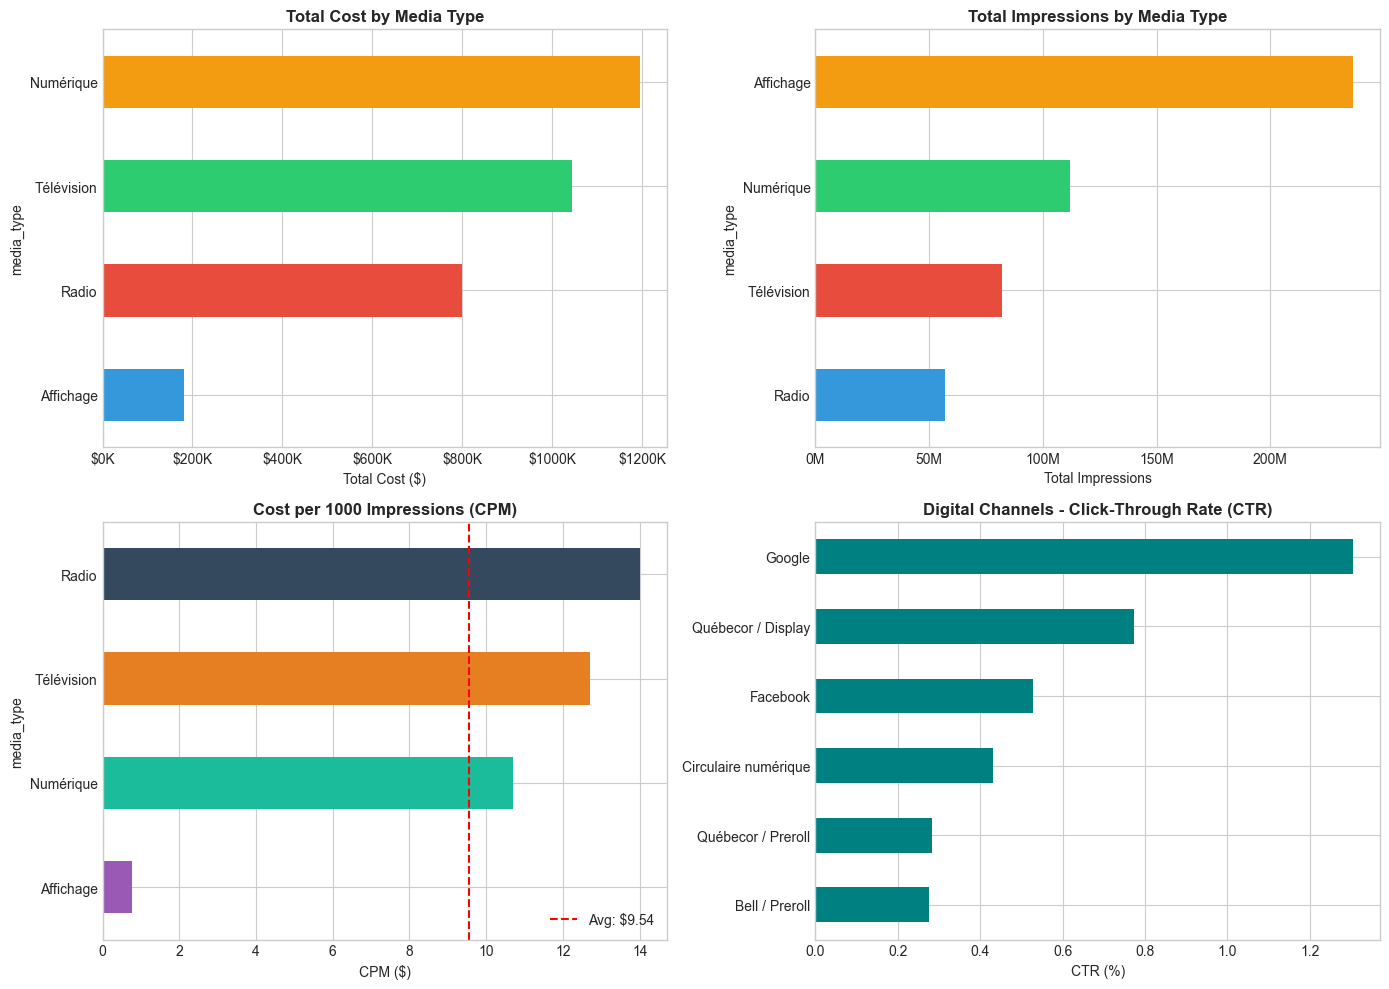


📈 Key Media Type Insights:
  - Digital (Numérique) has the lowest CPM and generates trackable clicks
  - TV has highest total spend and strong reach
  - Affichage (Billboard) has very high impressions at low CPM
  - Clicks/CTR only apply to digital media - TV/Radio/Billboard don't have click tracking


In [12]:
# Cell 12: Media Type Performance Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cost by media type
ax1 = axes[0, 0]
media_cost = tableau_medias.groupby('media_type')['cost_net'].sum().sort_values(ascending=True)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
media_cost.plot(kind='barh', ax=ax1, color=colors)
ax1.set_xlabel('Total Cost ($)')
ax1.set_title('Total Cost by Media Type', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 2: Impressions by media type
ax2 = axes[0, 1]
media_impr = tableau_medias.groupby('media_type')['impressions_reel'].sum().sort_values(ascending=True)
media_impr.plot(kind='barh', ax=ax2, color=colors)
ax2.set_xlabel('Total Impressions')
ax2.set_title('Total Impressions by Media Type', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

# Plot 3: CPM comparison
ax3 = axes[1, 0]
cpm_by_type = (tableau_medias.groupby('media_type')['cost_net'].sum() / 
               tableau_medias.groupby('media_type')['impressions_reel'].sum() * 1000)
cpm_by_type = cpm_by_type.sort_values(ascending=True)
cpm_by_type.plot(kind='barh', ax=ax3, color=['#9b59b6', '#1abc9c', '#e67e22', '#34495e'])
ax3.set_xlabel('CPM ($)')
ax3.set_title('Cost per 1000 Impressions (CPM)', fontsize=12, fontweight='bold')
ax3.axvline(x=cpm_by_type.mean(), color='red', linestyle='--', label=f'Avg: ${cpm_by_type.mean():.2f}')
ax3.legend()

# Plot 4: Digital-only click analysis (CTR by digital channel/support)
ax4 = axes[1, 1]
digital_channels = tableau_medias[tableau_medias['media_type'] == 'Numérique'].groupby('support').agg({
    'impressions_reel': 'sum',
    'clics_reel': 'sum',
    'cost_net': 'sum'
})
digital_channels['CTR'] = (digital_channels['clics_reel'] / digital_channels['impressions_reel'] * 100).fillna(0)
digital_channels = digital_channels.sort_values('cost_net', ascending=False).head(6)

if not digital_channels.empty:
    digital_channels['CTR'].sort_values(ascending=True).plot(kind='barh', ax=ax4, color='teal')
    ax4.set_xlabel('CTR (%)')
    ax4.set_title('Digital Channels - Click-Through Rate (CTR)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('')
else:
    ax4.text(0.5, 0.5, 'No digital channel data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Digital Channels - CTR', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_path / 'campaign_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Key Media Type Insights:")
print("  - Digital (Numérique) has the lowest CPM and generates trackable clicks")
print("  - TV has highest total spend and strong reach")
print("  - Affichage (Billboard) has very high impressions at low CPM")
print("  - Clicks/CTR only apply to digital media - TV/Radio/Billboard don't have click tracking")

---
## 6. MMM-Relevant Advanced Analysis

Key analyses to inform MMM model specification: lagged effects, multicollinearity, and de-seasonalized correlations.

In [ ]:
# Cell 13: Lagged Cross-Correlations (Adstock Exploration)

print("=" * 70)
print("LAGGED CROSS-CORRELATIONS (Carryover/Adstock Effects)")
print("=" * 70)
print("Testing if media spend at time t affects revenue at t+1, t+2, etc.")
print("This informs the decay rate for adstock transformations.\n")

spend_cols_analysis = [col for col in merged.columns if col.startswith('spend_') and col != 'spend_total']
max_lag = 3

# Compute lagged correlations
lag_results = {}
for channel in spend_cols_analysis:
    ch_name = channel.replace('spend_', '').replace('_', ' ').title()
    lag_results[ch_name] = {}
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = merged[channel].corr(merged['total_all_revenue'])
        else:
            corr = merged[channel].iloc[:-lag].reset_index(drop=True).corr(
                merged['total_all_revenue'].iloc[lag:].reset_index(drop=True))
        lag_results[ch_name][f'Lag-{lag}'] = corr

lag_df = pd.DataFrame(lag_results).T
print(lag_df.round(3).to_string())

# Find best lag for each channel
print("\n--- Best Lag per Channel ---")
for ch_name, lags in lag_results.items():
    best_lag = max(lags, key=lambda k: abs(lags[k]))
    best_corr = lags[best_lag]
    print(f"  {ch_name:<25} Best: {best_lag} (r={best_corr:+.3f})")

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, (ch_name, lags) in enumerate(lag_results.items()):
    if i >= 7: break
    ax = axes[i]
    lag_vals = [lags[f'Lag-{l}'] for l in range(max_lag + 1)]
    colors = ['coral' if v == max(lag_vals, key=abs) else 'steelblue' for v in lag_vals]
    ax.bar(range(max_lag + 1), lag_vals, color=colors, edgecolor='navy')
    ax.set_title(ch_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.set_xticks(range(max_lag + 1))
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_ylim(-0.5, 1.0)

if len(lag_results) < 8:
    axes[7].set_visible(False)

plt.suptitle('Lagged Correlations: Media Spend → Total Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path / 'lagged_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - Lag-0: Same-month effect (immediate impact)")
print("  - Lag-1: Spend this month → revenue next month (carryover)")
print("  - Channels with best correlation at Lag-1+ suggest adstock/carryover effects")
print("  - Channels best at Lag-0 suggest immediate impact or seasonal confounding")

In [ ]:
# Cell 13b: Multicollinearity Analysis (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 70)
print("MULTICOLLINEARITY ANALYSIS (Variance Inflation Factor)")
print("=" * 70)
print("VIF > 5 indicates high multicollinearity. VIF > 10 is severe.\n")

spend_cols_vif = [col for col in merged.columns if col.startswith('spend_') and col != 'spend_total']

# Calculate VIF for spend variables
X = merged[spend_cols_vif].copy()
X = X.loc[:, X.std() > 0]  # Drop zero-variance columns

vif_data = pd.DataFrame()
vif_data['Channel'] = [c.replace('spend_', '').replace('_', ' ').title() for c in X.columns]
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = " *** HIGH" if row['VIF'] > 5 else " ** MODERATE" if row['VIF'] > 2.5 else ""
    print(f"  {row['Channel']:<25} VIF = {row['VIF']:.2f}{flag}")

# Spend-spend correlation heatmap
print("\n--- Channel-to-Channel Correlation Matrix ---")
spend_corr = merged[spend_cols_vif].corr()
spend_labels = [c.replace('spend_', '').replace('_', ' ').title() for c in spend_cols_vif]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(spend_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1,
            xticklabels=spend_labels, yticklabels=spend_labels)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Media Channel Correlation Matrix (Multicollinearity Check)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path / 'channel_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImplications for MMM:")
print("  - High VIF channels may need to be combined or regularized")
print("  - Ridge/elastic net regularization helps with multicollinearity")
print("  - Bayesian MMM frameworks (e.g., PyMC-Marketing) handle this through priors")

In [ ]:
# Cell 13c: De-Seasonalized Correlations

print("=" * 70)
print("DE-SEASONALIZED CORRELATIONS")
print("=" * 70)
print("Removing monthly seasonality to isolate true media effects.\n")

# Create monthly dummies and residualize
from sklearn.linear_model import LinearRegression

month_dummies = pd.get_dummies(merged['month_num'], prefix='m', drop_first=True)

spend_cols_deseason = [col for col in merged.columns if col.startswith('spend_') and col != 'spend_total']
target_cols_deseason = ['total_all_revenue'] + list(product_cols.keys())

# Residualize each variable against monthly dummies
residuals = {}
lr = LinearRegression()

for col in target_cols_deseason + spend_cols_deseason:
    lr.fit(month_dummies, merged[col])
    residuals[col] = merged[col] - lr.predict(month_dummies)

resid_df = pd.DataFrame(residuals)

# Compute de-seasonalized correlations
print("--- De-seasonalized: Total Revenue vs Media Spend ---")
print(f"\n{'Channel':<25} {'Raw r':>8} {'De-season r':>12} {'Change':>8}")
print("-" * 55)

for channel in spend_cols_deseason:
    ch_name = channel.replace('spend_', '').replace('_', ' ').title()
    raw_corr = merged[channel].corr(merged['total_all_revenue'])
    deseason_corr = resid_df[channel].corr(resid_df['total_all_revenue'])
    change = deseason_corr - raw_corr
    signal = "SIGNAL" if abs(deseason_corr) > 0.3 else "weak"
    print(f"  {ch_name:<23} {raw_corr:>+.3f}   {deseason_corr:>+.3f}      {change:>+.3f}  {signal}")

# Per-category de-seasonalized correlations
print("\n--- De-seasonalized: Per Category vs Media Spend ---")
deseason_matrix = pd.DataFrame(index=spend_cols_deseason, 
                                columns=list(product_cols.keys()))
for channel in spend_cols_deseason:
    for cat in product_cols.keys():
        deseason_matrix.loc[channel, cat] = resid_df[channel].corr(resid_df[cat])

deseason_matrix = deseason_matrix.astype(float)
deseason_matrix.index = [c.replace('spend_', '').replace('_', ' ').title() for c in deseason_matrix.index]
deseason_matrix.columns = [product_cols[c] for c in deseason_matrix.columns]
print(deseason_matrix.round(3).to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Raw vs De-seasonalized for total revenue
ax1 = axes[0]
ch_names = [c.replace('spend_', '').replace('_', ' ').title() for c in spend_cols_deseason]
raw_corrs = [merged[c].corr(merged['total_all_revenue']) for c in spend_cols_deseason]
deseason_corrs = [resid_df[c].corr(resid_df['total_all_revenue']) for c in spend_cols_deseason]

x = np.arange(len(ch_names))
width = 0.35
ax1.barh(x - width/2, raw_corrs, width, label='Raw', color='steelblue', alpha=0.8)
ax1.barh(x + width/2, deseason_corrs, width, label='De-seasonalized', color='coral', alpha=0.8)
ax1.set_yticks(x)
ax1.set_yticklabels(ch_names)
ax1.set_xlabel('Correlation with Total Revenue')
ax1.set_title('Raw vs De-Seasonalized Correlations', fontsize=13, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)
ax1.legend()

# Right: De-seasonalized per-category heatmap
ax2 = axes[1]
sns.heatmap(deseason_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax2, vmin=-0.6, vmax=0.6)
ax2.set_title('De-Seasonalized: Channel vs Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_path / 'deseasonalized_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Findings:")
print("  - Channels where de-seasonalized r remains strong have genuine media effects")
print("  - Channels where r drops to near-zero were mainly seasonal confounding")
print("  - Per-category patterns reveal which channels drive which products")

---
## 8. Summary & Next Steps

In [ ]:
# Cell 14: EDA Summary

print("="*70)
print("EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("="*70)

print("""
DATA OVERVIEW:
  - 36 months of aligned fiscal year data (FY2023-FY2025)
  - 6 product categories (all equal): HT, CR, SP, ME&GA, FI, BQ
  - 7 media channel groups
  - Target variable: total_all_revenue (sum of all 6 categories)
  - Merged dataset loaded from NB02 (sales_spend_merged.pkl)

DISTRIBUTIONS:
  - Revenue: right-skewed (seasonal peaks drive high-end values)
  - Spend: significant zero-inflation in Panneaux (75%), TV (44%), Circulaire (44%)
  - Banniere_Web and Social_Media have spend every month (0% zero)

SEASONALITY:
  - Peak: March-June | Low: November-February
  - Both revenue and media spend share seasonal patterns

CORRELATION INSIGHTS:
  - Raw correlations may be inflated by shared seasonality
  - De-seasonalized analysis reveals true media signals
  - Per-category correlations show differential channel effects

MULTICOLLINEARITY:
  - Some channels have high VIF (check output above)
  - MMM should use regularization or Bayesian priors

LAGGED EFFECTS:
  - Some channels show stronger correlation at Lag-1 (carryover)
  - Informs adstock decay rates for MMM specification

NEXT STEPS:
  1. Notebook 04: Add weather/external data
  2. Notebook 05: Feature engineering (adstock, saturation)
  3. Notebook 06: Build MMM model
""")